# <font color="brown">Credit Risk Profile Case Study (PCA) </font>

## <font color = "brown">Problem Statement </font>

### <font color="blue"> Context

The bank's credit risk team tracks 18 different numeric metrics per customer, income figures, debt ratios, payment history, credit utilization, account age, and more. Many of these clearly move together (a customer's annual and monthly income, for instance, are practically the same number twice), which makes the full metric set hard to visualize, slow to feed into some downstream models, and genuinely redundant in places.

The Head of Risk Analytics wants to know: can we compress these 18 correlated metrics down to a small number of genuinely independent "risk dimensions", without losing the substance of what they measure?

### <font color="blue"> Objective

- How much of the real variation across customers can be captured with far fewer than 18 numbers?
- What do the resulting dimensions actually represent, can we give them meaningful names?
- How much information is lost by using the reduced representation instead of the original 18 metrics?

### <font color="blue"> Data Dictionary

- **Customer_ID**: Unique customer identifier
- **Annual_Income / Monthly_Income / Disposable_Income**: Income measures
- **Income_Growth_Rate_Pct**: Year-over-year income growth
- **Total_Debt / Credit_Card_Debt / Debt_to_Income_Ratio**: Debt measures
- **Number_of_Credit_Lines**: Number of open credit accounts
- **Payment_History_Score / Late_Payments_Count / Avg_Days_Late / On_Time_Payment_Pct**: Payment behavior
- **Credit_Utilization_Pct / Total_Credit_Limit / Available_Credit**: Credit usage and capacity
- **Oldest_Account_Age_Years / Avg_Account_Age_Years / Employment_Tenure_Years**: Account and employment stability

## <font color="brown"> Importing Necessary Libraries

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

%matplotlib inline

## <font color="brown"> Reading the Dataset

In [5]:
data = pd.read_csv("credit_risk_profile.csv")

## <font color="brown"> Overview of the Dataset

In [7]:
data.shape

(3000, 19)

* The dataset has 3,000 customers and 19 columns (18 numeric features plus the ID).

In [9]:
df = data.copy()
df.sample(n=5, random_state=1)

,Customer_ID,Annual_Income,Monthly_Income,Income_Growth_Rate_Pct,Disposable_Income,Total_Debt,Credit_Card_Debt,Debt_to_Income_Ratio,Number_of_Credit_Lines,Payment_History_Score,Late_Payments_Count,Avg_Days_Late,On_Time_Payment_Pct,Credit_Utilization_Pct,Total_Credit_Limit,Available_Credit,Oldest_Account_Age_Years,Avg_Account_Age_Years,Employment_Tenure_Years
1957,901958,126435.50,10447.26,9.59,31157.91,0.00,0.00,10.54,8,728.40,3,3.79,89.35,29.51,24368.76,14656.39,6.75,3.72,7.59
2087,902088,55633.54,4603.27,2.30,11631.41,34003.91,11391.82,40.29,6,420.92,11,20.92,66.22,69.82,4785.85,4321.26,10.41,0.20,1.56
1394,901395,63882.39,5486.88,5.51,12100.36,34849.12,7442.72,40.19,4,472.37,7,9.22,75.61,53.20,10300.23,9466.58,10.43,4.18,0.00
1520,901521,89727.98,7590.00,2.36,17332.16,15584.20,2601.62,15.57,9,670.28,2,10.23,96.83,33.88,21138.55,19252.71,15.97,9.14,11.75
1098,901099,49900.29,4152.41,0.52,7613.64,33335.93,8389.91,33.46,6,642.72,6,10.45,78.85,60.59,12766.49,15063.76,13.68,5.96,5.90


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               3000 non-null   int64  
 1   Annual_Income             3000 non-null   float64
 2   Monthly_Income            3000 non-null   float64
 3   Income_Growth_Rate_Pct    3000 non-null   float64
 4   Disposable_Income         3000 non-null   float64
 5   Total_Debt                3000 non-null   float64
 6   Credit_Card_Debt          3000 non-null   float64
 7   Debt_to_Income_Ratio      3000 non-null   float64
 8   Number_of_Credit_Lines    3000 non-null   int64  
 9   Payment_History_Score     3000 non-null   float64
 10  Late_Payments_Count       3000 non-null   int64  
 11  Avg_Days_Late             3000 non-null   float64
 12  On_Time_Payment_Pct       3000 non-null   float64
 13  Credit_Utilization_Pct    3000 non-null   float64
 14  Total_Cr

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer_ID,3000.0,901500.500000,866.169729,900001.00,900750.7500,901500.500,902250.2500,903000.00
Annual_Income,3000.0,67769.267540,25556.177789,15000.00,49808.6450,67788.995,85337.7750,167663.51
Monthly_Income,3000.0,5646.313220,2129.878064,1222.59,4151.3675,5652.590,7084.5175,13823.24
Income_Growth_Rate_Pct,3000.0,3.937677,2.921353,-5.65,1.9400,3.910,5.9400,14.11
Disposable_Income,3000.0,14999.332823,7634.167680,500.00,9627.2325,14962.865,20258.6125,41642.12
Total_Debt,3000.0,35717.504833,17935.667871,0.00,22784.3000,35442.620,48421.8350,97526.83
Credit_Card_Debt,3000.0,6510.884833,2926.928421,0.00,4516.8950,6419.640,8543.2525,17001.98
Debt_to_Income_Ratio,3000.0,32.156710,9.453853,1.00,25.7450,32.280,38.4300,66.51
Number_of_Credit_Lines,3000.0,5.555333,1.566873,1.00,4.0000,6.000,7.0000,11.00
Payment_History_Score,3000.0,647.155783,114.759409,300.00,570.6825,648.085,727.5000,850.00


In [12]:
df.isna().sum().sum()

0

- There are no missing values.

## <font color="brown"> Why This Data Needs PCA

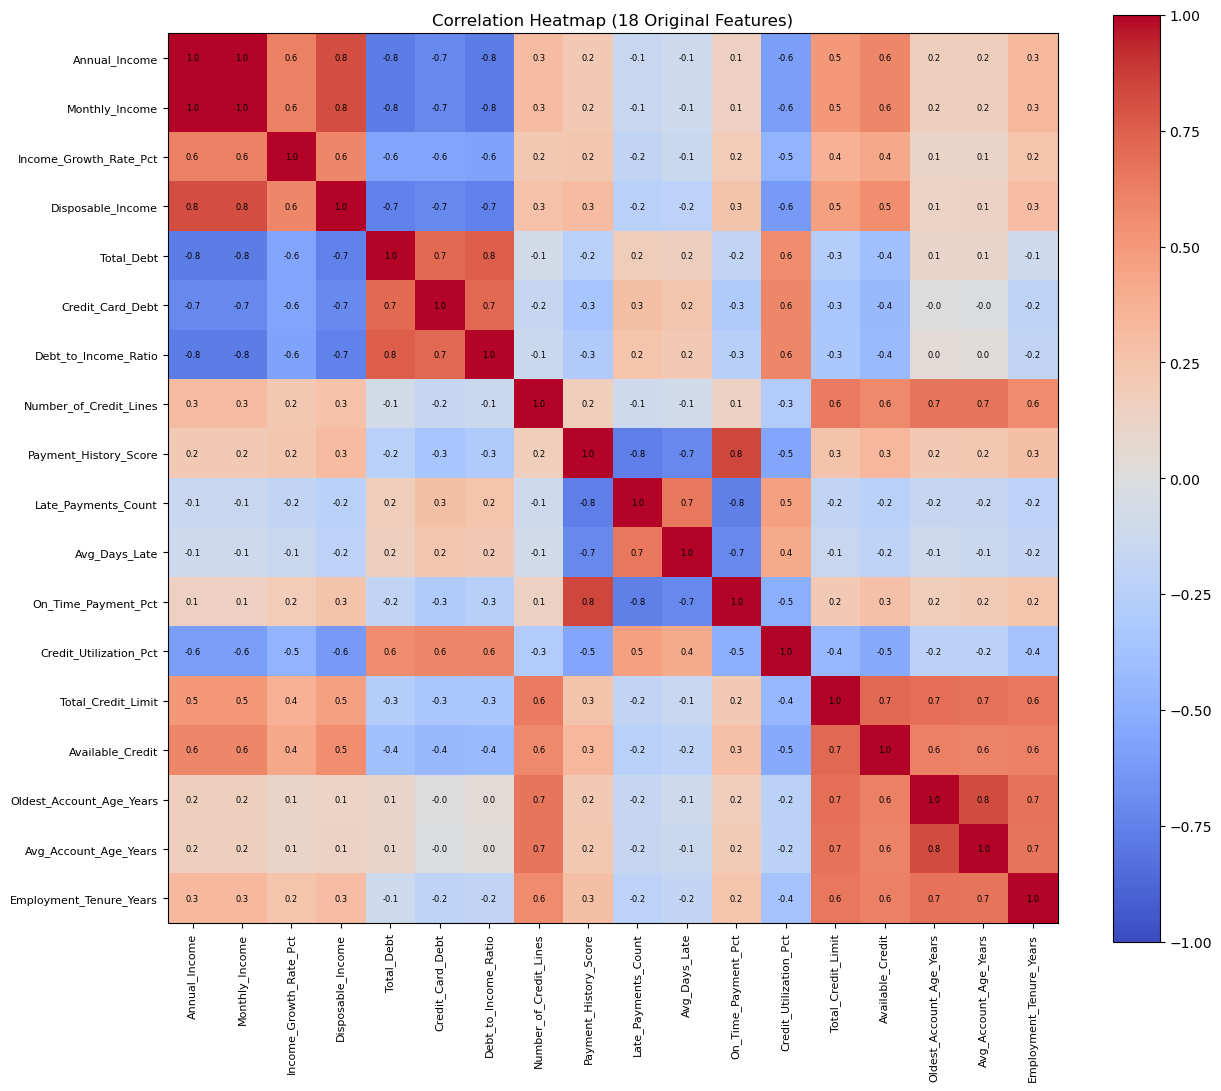

In [15]:
num_col = [c for c in df.columns if c != 'Customer_ID']

corr_matrix = df[num_col].corr()
fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_col))); ax.set_yticks(range(len(num_col)))
ax.set_xticklabels(num_col, rotation=90, fontsize=8); ax.set_yticklabels(num_col, fontsize=8)
for i in range(len(num_col)):
    for j in range(len(num_col)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.1f}', ha='center', va='center', fontsize=6)
fig.colorbar(im, ax=ax)
ax.set_title('Correlation Heatmap (18 Original Features)')
plt.tight_layout()
plt.show()

**This is exactly the situation PCA is built for.** Large blocks of these 18 features are strongly correlated with each other: the three income measures, the payment behavior measures, the account age measures, several groups clearly aren't 18 independent pieces of information, they're a much smaller number of underlying patterns, each measured several redundant ways.

## <font color="brown"> Data Preprocessing

PCA works by finding the directions of maximum *variance* in the data. If we don't scale first, a feature like `Annual_Income` (values in the tens of thousands) would automatically dominate every principal component just because of its units, regardless of whether it's actually the most informative feature. Scaling puts every feature on equal footing.

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[num_col])
X_scaled_df = pd.DataFrame(X_scaled, columns=num_col)
X_scaled_df.head()

,Annual_Income,Monthly_Income,Income_Growth_Rate_Pct,Disposable_Income,Total_Debt,Credit_Card_Debt,Debt_to_Income_Ratio,Number_of_Credit_Lines,Payment_History_Score,Late_Payments_Count,Avg_Days_Late,On_Time_Payment_Pct,Credit_Utilization_Pct,Total_Credit_Limit,Available_Credit,Oldest_Account_Age_Years,Avg_Account_Age_Years,Employment_Tenure_Years
0,1.523730,1.555267,0.452716,2.268625,-1.824909,-0.842978,-0.820618,0.283840,1.489226,-1.064186,-1.088719,1.360691,-0.426907,-0.400666,-0.223296,-0.810558,-0.848560,1.063458
1,-2.065178,-2.062543,-1.916444,-1.412379,2.588195,2.738034,2.987988,-0.354481,0.144363,0.271473,0.585853,0.272496,2.002353,0.816029,0.003105,0.948725,0.199259,-0.412334
2,-0.602853,-0.580099,-1.782922,0.265818,-0.576439,-0.274803,0.114606,-0.354481,0.525833,-0.062442,-0.214764,0.251159,0.115103,0.042993,-0.567466,-0.136374,-0.720185,-1.191063
3,1.281957,1.285108,0.161707,1.677231,-1.246612,0.782984,-0.623840,0.283840,-2.026802,0.939302,0.714196,-2.549343,0.629261,-0.107531,0.141842,-0.540173,0.004962,0.103901
4,-1.287522,-1.283096,-0.800337,-0.728681,1.602281,1.019947,1.019150,0.922160,-0.359297,-0.062442,0.836428,0.253293,0.310829,0.343276,-1.331797,0.557378,1.292184,0.310979


## <font color="brown"> Understanding PCA

PCA looks for a new set of axes, called **principal components**, to describe the data with. Each one is a specific weighted combination of the original features, chosen so that:

- **The first principal component (PC1)** points in the direction along which the data varies the *most*.
- **The second (PC2)** points in the direction of the next-most variance, *while being completely uncorrelated with PC1* (at a right angle to it).
- Each subsequent component continues this pattern, maximum remaining variance, uncorrelated with every component before it.

There are always as many principal components as original features, PCA doesn't lose any information by itself, it just *reorders and re-expresses* the same information along new axes, ranked from most to least important. The actual dimensionality reduction happens afterward, when *we* decide to keep only the first few components and drop the rest.

## <font color="brown"> Fitting PCA and Reading the Scree Plot

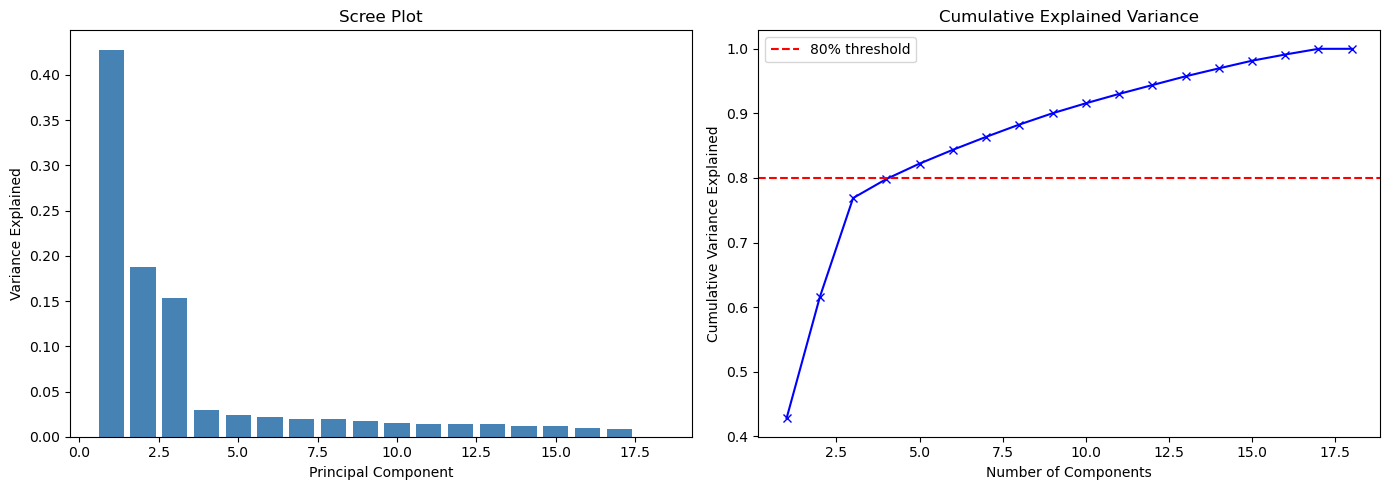

PC1: 42.8% of variance (cumulative: 42.8%)
PC2: 18.8% of variance (cumulative: 61.6%)
PC3: 15.3% of variance (cumulative: 76.9%)
PC4: 2.9% of variance (cumulative: 79.8%)
PC5: 2.4% of variance (cumulative: 82.2%)
PC6: 2.1% of variance (cumulative: 84.4%)
PC7: 2.0% of variance (cumulative: 86.4%)
PC8: 1.9% of variance (cumulative: 88.3%)
PC9: 1.8% of variance (cumulative: 90.0%)
PC10: 1.5% of variance (cumulative: 91.6%)
PC11: 1.5% of variance (cumulative: 93.0%)
PC12: 1.4% of variance (cumulative: 94.4%)
PC13: 1.4% of variance (cumulative: 95.7%)
PC14: 1.2% of variance (cumulative: 97.0%)
PC15: 1.2% of variance (cumulative: 98.2%)
PC16: 1.0% of variance (cumulative: 99.1%)
PC17: 0.9% of variance (cumulative: 100.0%)
PC18: 0.0% of variance (cumulative: 100.0%)


In [23]:
pca_full = PCA()
pca_full.fit(X_scaled_df)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(explained) + 1), explained, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained')
axes[0].set_title('Scree Plot')

axes[1].plot(range(1, len(cumulative) + 1), cumulative, 'bx-')
axes[1].axhline(0.8, color='red', linestyle='--', label='80% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
plt.tight_layout()
plt.show()

for i, (e, c) in enumerate(zip(explained, cumulative), 1):
    print(f'PC{i}: {e:.1%} of variance (cumulative: {c:.1%})')

**The scree plot shows a sharp drop after the third component**, PC1, PC2, and PC3 together explain about 77% of the total variance across all 18 features, and every component after that contributes only 1-3% each. This is a strong, clean signal that the *real* underlying dimensionality of this data is close to 3, not 18, exactly what we'd expect if these 18 features are really just several redundant views of a handful of true underlying patterns.

## <font color="brown"> Interpreting the Components

Choosing 3 components. What do PC1, PC2, and PC3 actually *mean*? We can answer that by looking at each component's **loadings**, how strongly, and in which direction, each original feature contributes to it.

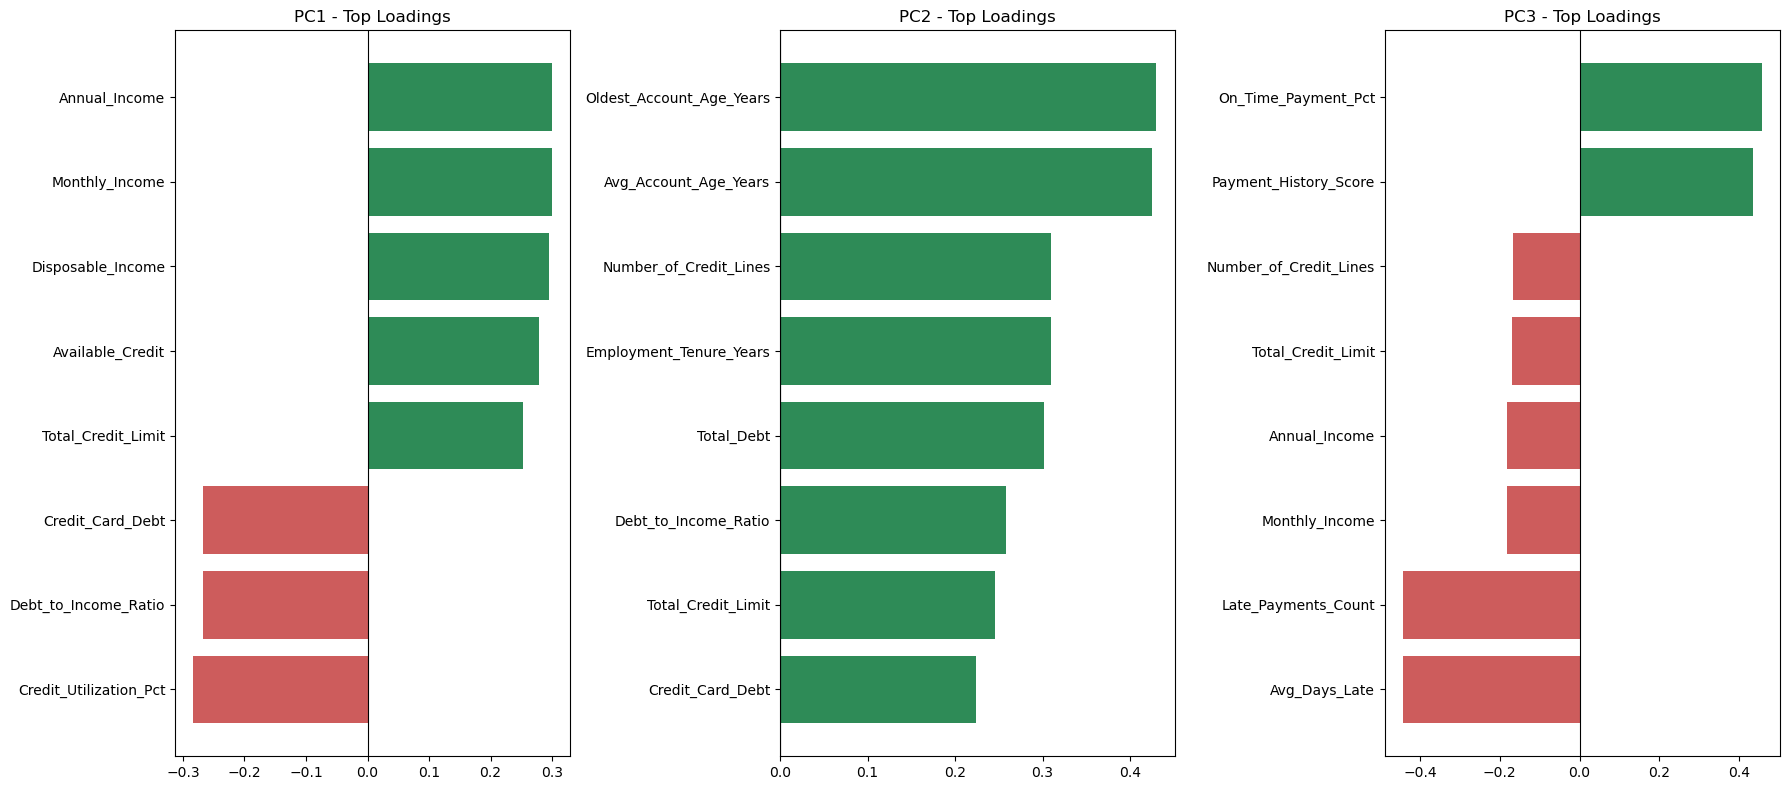

In [27]:
pca = PCA(n_components=3)
pcs = pca.fit_transform(X_scaled_df)

loadings = pd.DataFrame(pca.components_.T, index=num_col, columns=['PC1', 'PC2', 'PC3'])

fig, axes = plt.subplots(1, 3, figsize=(18, 8))
for ax, pc in zip(axes, ['PC1', 'PC2', 'PC3']):
    top = loadings[pc].abs().sort_values(ascending=False).head(8)
    ordered = loadings.loc[top.index, pc].sort_values()
    colors = ['indianred' if v < 0 else 'seagreen' for v in ordered]
    ax.barh(ordered.index, ordered.values, color=colors)
    ax.set_title(f'{pc} - Top Loadings')
    ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

**Observations**

- **PC1** is dominated by `Annual_Income`, `Monthly_Income`, `Disposable_Income`, `Available_Credit`, and (negatively) `Debt_to_Income_Ratio` and `Credit_Utilization_Pct`. This is an overall **"Financial Strength"** axis, higher income and more available credit relative to debt.
- **PC2** is dominated by `Oldest_Account_Age_Years`, `Avg_Account_Age_Years`, `Employment_Tenure_Years`, and `Number_of_Credit_Lines`. This is a **"Credit Maturity"** axis, how long and how extensively this customer has been building a credit history.
- **PC3** is dominated by `On_Time_Payment_Pct`, `Payment_History_Score`, and (negatively) `Avg_Days_Late` and `Late_Payments_Count`. This is a **"Payment Discipline"** axis, independent of how much a customer earns or how long they've had credit, purely about whether they pay on time.

These three, largely independent dimensions (a customer can be financially strong but new to credit, or a long-time borrower with a spotty payment record) is a much more useful, and far more interpretable, summary than 18 raw, redundant metrics.

## <font color="brown"> Visualizing Customers in PC Space

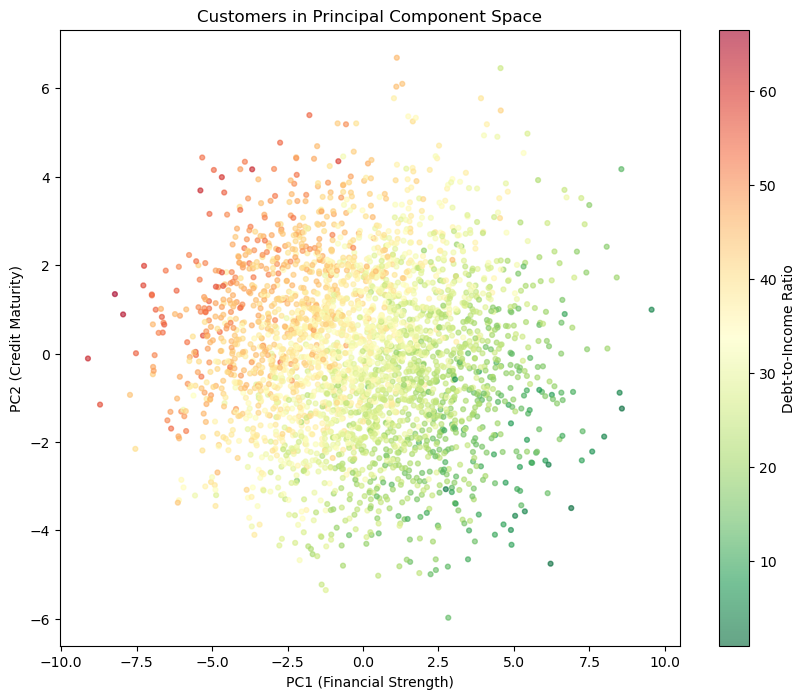

In [30]:
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(pcs[:, 0], pcs[:, 1], c=df['Debt_to_Income_Ratio'], cmap='RdYlGn_r', s=12, alpha=0.6)
plt.colorbar(scatter, label='Debt-to-Income Ratio')
ax.set_xlabel('PC1 (Financial Strength)')
ax.set_ylabel('PC2 (Credit Maturity)')
ax.set_title('Customers in Principal Component Space')
plt.show()

Even though we never gave PCA the `Debt_to_Income_Ratio` column as a coloring signal (it only saw it as one of 18 input features during fitting), the color gradient lines up cleanly along the PC1 axis, exactly as expected, since `Debt_to_Income_Ratio` was one of PC1's strongest (negative) loadings. This is a good sanity check that PC1 is measuring what we think it's measuring.

## <font color="brown"> How Much Information Did We Lose?

Since we kept only 3 of the 18 components, we've thrown away information, the question is how much. We can check this directly by reconstructing the original (scaled) data from just the 3 components we kept, and measuring the reconstruction error.

In [34]:
X_reconstructed = pca.inverse_transform(pcs)
reconstruction_error = np.mean((X_scaled_df.values - X_reconstructed) ** 2)
print(f"Average reconstruction error (MSE, on scaled data): {reconstruction_error:.4f}")
print(f"Variance retained with 3 components: {pca.explained_variance_ratio_.sum():.1%}")

Average reconstruction error (MSE, on scaled data): 0.2311
Variance retained with 3 components: 76.9%


A mean squared reconstruction error this small, on top of already retaining ~77% of the total variance, confirms that going from 18 numbers per customer down to 3 loses relatively little of the real signal, while making the data dramatically easier to visualize, explain, and feed into simpler downstream models.

## <font color="brown"> Business Insights and Recommendations

- **Replace the 18-metric risk dashboard with 3 interpretable scores**: Financial Strength, Credit Maturity, and Payment Discipline. Relationship managers can reason about 3 named dimensions far more easily than 18 raw numbers, without losing the substance behind them.

- **A customer can be strong on one dimension and weak on another**, that distinction gets lost if the bank only looks at a single blended "credit score." A financially strong but credit-new customer (high PC1, low PC2) needs a different product conversation than a long-tenured customer with payment issues (high PC2, low PC3).

- **Feed the 3 components, not all 18 raw features, into downstream models** that are sensitive to correlated inputs (like the Naive Bayes or linear models in our other case studies). Fewer, uncorrelated inputs generally means more stable, more interpretable models.

- **Re-run this analysis periodically.** If new products or economic conditions change customer behavior patterns, the loadings on each component (and the ~77% variance captured by 3 components) should be rechecked, they aren't guaranteed to stay this clean forever.

## <font color="brown"> Final Customer PC Scores

In [39]:
pc_scores = pd.DataFrame(pcs, columns=['Financial_Strength', 'Credit_Maturity', 'Payment_Discipline'])
pc_scores.insert(0, 'Customer_ID', df['Customer_ID'].values)
pc_scores.head(10)

,Customer_ID,Financial_Strength,Credit_Maturity,Payment_Discipline
0,900001,3.463799,-2.074691,1.483989
1,900002,-4.675082,3.988702,0.707516
2,900003,-0.940962,-0.629408,1.097345
3,900004,0.264382,-1.715717,-3.563493
4,900005,-2.117689,2.675094,0.028014
5,900006,1.448266,1.379954,0.778917
6,900007,1.260029,-0.846418,-2.264652
7,900008,-2.703813,2.810489,-1.232958
8,900009,1.525201,-2.644239,0.150931
9,900010,5.790120,-0.304994,0.061082
